# W9 biological interpretation and error diagnostics

## tl;dr

24h observed response PC1은 trametinib sensitivity와 강하게 연결됐다
(Spearman ρ −0.668), BRAF/KRAS 상태와 lineage도 같은 축과 연관됐다.
Sensitivity가 높을수록 E2F/G2M 및 immediate-early score가 더 음수였다.
B4 오차는 관측 반응 크기(ρ 0.973)와 조건별 최소 세포 수(ρ −0.775)에 크게
좌우됐지만, fold-fitted baseline novelty와는 연관되지 않았다. 두 오차 요인은
서로를 통제한 뒤에도 남아 큰 실제/관측 반응과 낮은 측정 지원이 함께 난도를
높였음을 시사한다. 이 분석의 sensitivity·mutation은 해석용이며 predictor가 아니다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
summary = json.loads((root / "results/logs/biology_summary.json").read_text())
validation = json.loads((root / "results/logs/biology_validation.json").read_text())
associations = pd.read_csv(root / "results/tables/biological_validation.csv")
targets = pd.read_csv(root / "results/tables/target_gene_validation.csv")
enrichment = pd.read_csv(root / "results/tables/biological_pathway_enrichment.csv")
cases = pd.read_csv(root / "results/tables/prediction_cases.csv")
errors = pd.read_csv(root / "results/tables/error_classification.csv")

display(pd.DataFrame({
    "metric": ["cell lines", "association tests", "FDR < 0.05",
               "target genes", "high-error lines"],
    "value": [summary["cell_lines"], summary["association_tests"],
              summary["significant_fdr05"], summary["target_genes"],
              summary["high_error_lines"]],
}))
assert validation["status"] == "passed"
assert validation["interpretation_only"] is True
assert validation["sensitivity_used_as_predictor"] is False


,metric,value
0,cell lines,94
1,association tests,38
2,FDR < 0.05,22
3,target genes,15
4,high-error lines,24


## Context & Methods

### Key Assumptions

- 분석 단위는 94개 held-out evaluation cell line이며 cell-level p-value를 쓰지 않는다.
- response PCA는 전체 관측 반응을 요약하는 기술적 해석 축이고 PC 부호는 임의다.
- 연속형 연결은 Spearman, cell-line bootstrap 95% CI, 10,000회 permutation을 쓴다.
- mutation은 Cliff's delta, lineage는 global eta-squared label permutation으로 본다.
- 총 38개 association p-value를 하나의 BH-FDR family로 보정한다.
- baseline novelty는 각 outer fold의 training control에서만 fit한 whitened PC20에서
  가장 가까운 training line까지의 거리다.
- sensitivity, lineage, mutation은 W9 해석에만 쓰며 B4/CCLR predictor나 선택 기준이 아니다.

## Results

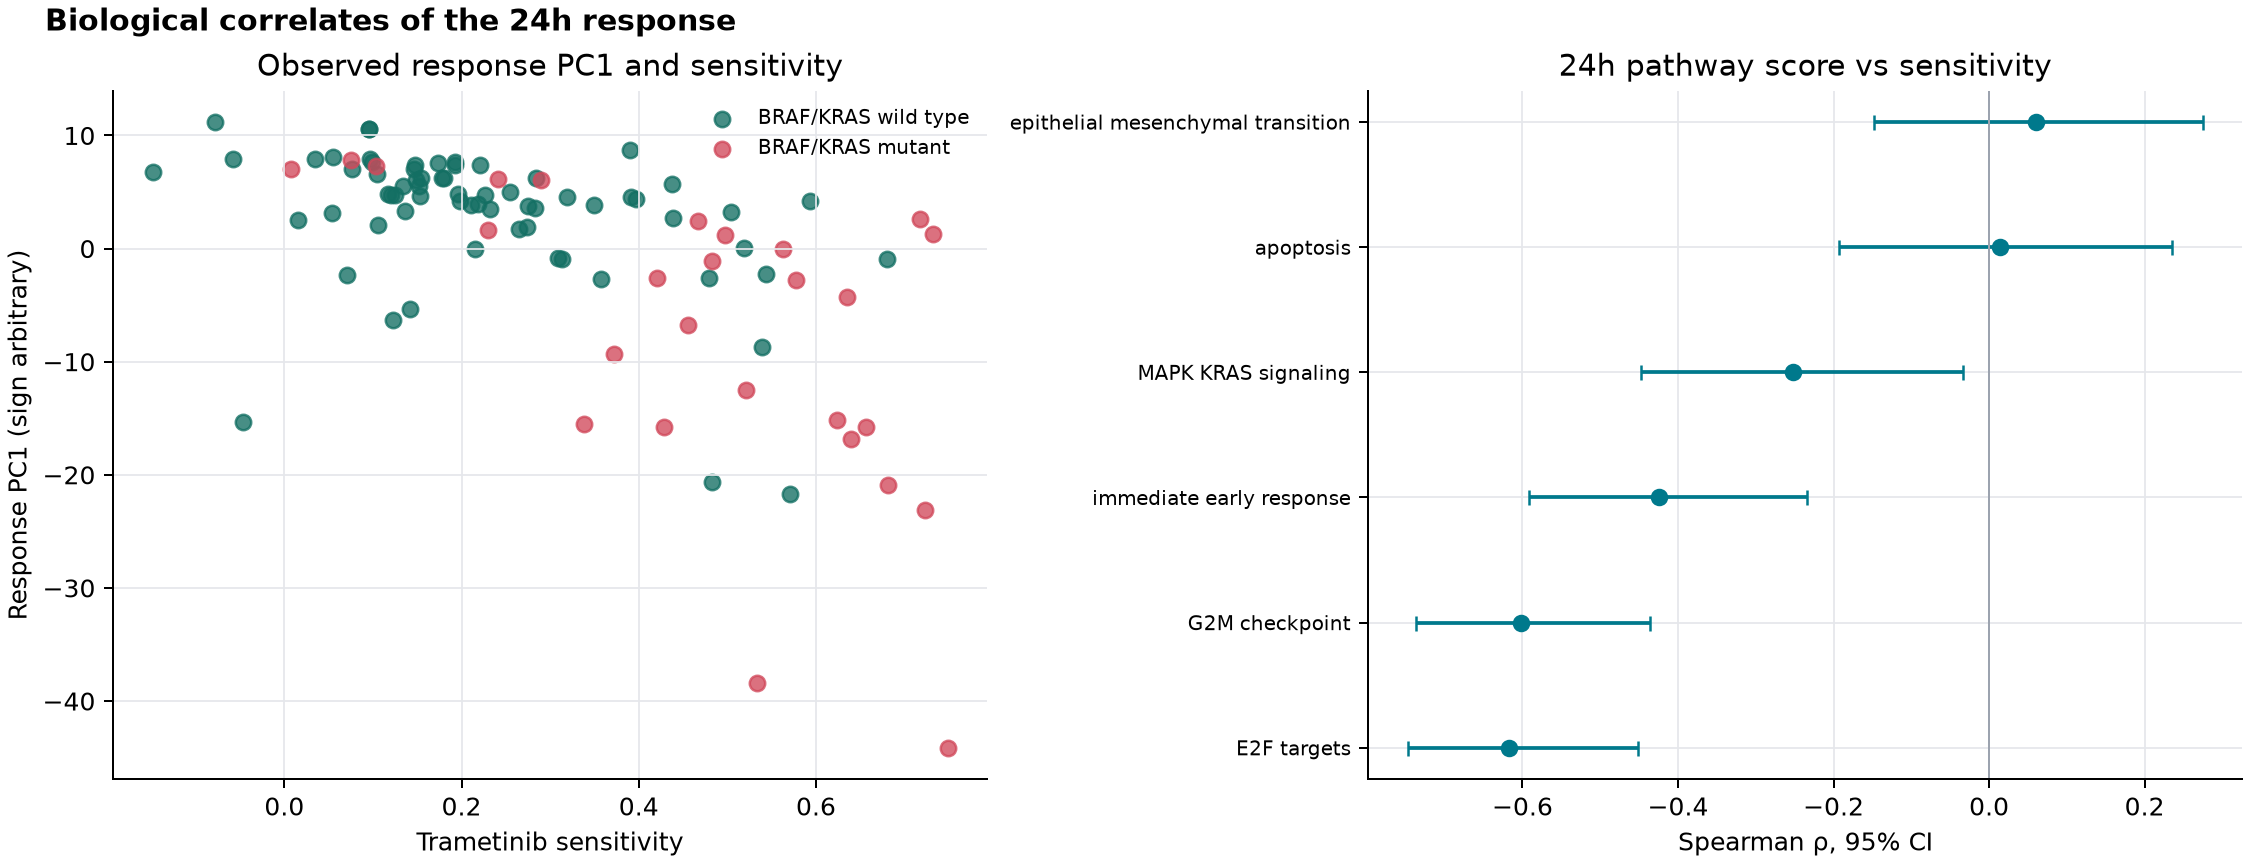

,family,outcome,predictor,effect,ci95_low,ci95_high,fdr_bh
0,component_sensitivity,response_pc1,trametinib_sensitivity,-0.668273,-0.786058,-0.502658,0.000317
1,component_mutation,response_pc1,braf_mut,-0.581395,-0.898256,-0.180233,0.007124
2,component_mutation,response_pc1,kras_mut,-0.423158,-0.657544,-0.153684,0.017943
3,component_lineage,response_pc1,lineage_global,0.549362,NaN,NaN,0.002280
5,component_mutation,response_pc2,braf_mut,-0.715116,-0.956395,-0.334302,0.001357
8,component_sensitivity,response_pc3,trametinib_sensitivity,0.234447,0.020037,0.426052,0.041416
12,component_sensitivity,response_pc4,trametinib_sensitivity,-0.414326,-0.599793,-0.206769,0.000317
14,component_mutation,response_pc4,kras_mut,-0.347368,-0.670175,-0.016105,0.045595
16,component_sensitivity,response_pc5,trametinib_sensitivity,-0.281176,-0.473121,-0.076386,0.015198
20,pathway_sensitivity,MAPK_KRAS_signaling,trametinib_sensitivity,-0.252465,-0.446934,-0.033180,0.026597


,gene_symbol,mapped_columns,mean_delta_log1p_cpm,mean_ci95_low,mean_ci95_high,sensitivity_spearman,spearman_ci95_low,spearman_ci95_high,p_value,fdr_bh
0,EGR1,1,-2.669841,-2.826488,-2.503505,0.018892,-0.201709,0.237815,0.855714,0.855714
1,ETV4,1,-2.467274,-2.650139,-2.272461,-0.464119,-0.615735,-0.282050,0.000100,0.000214
2,ETV5,1,-1.875740,-2.036700,-1.712904,-0.357786,-0.537704,-0.163507,0.001300,0.002166
3,DUSP4,1,-1.431943,-1.591950,-1.279826,-0.220879,-0.405991,-0.013353,0.029697,0.034266
4,DUSP5,1,-1.106030,-1.235890,-0.974272,-0.152288,-0.365406,0.073638,0.139386,0.149342
5,DUSP6,1,-2.394439,-2.583798,-2.213876,-0.321909,-0.501942,-0.103481,0.001600,0.002400
6,SPRY2,1,-0.996646,-1.151837,-0.845068,-0.254720,-0.452613,-0.039809,0.013399,0.018271
7,SPRY4,1,-1.305015,-1.444993,-1.165176,-0.227180,-0.423371,-0.022155,0.028497,0.034266
8,MCM2,1,-0.388641,-0.502394,-0.281430,-0.423646,-0.607026,-0.202111,0.000200,0.000375
9,MCM3,1,-0.511347,-0.611892,-0.417169,-0.453065,-0.621406,-0.263638,0.000100,0.000214


,component,direction,pathway,top_gene_count,pathway_gene_count,overlap_count,overlap_genes,p_value,fdr_bh
8,1,positive,G2M_checkpoint,50,187,15,AURKB;CCNA2;CCND1;CDC25A;CDC45;CDC6;CDK1;CENPA...,2.504838e-22,1.502903e-20
7,1,positive,E2F_targets,50,195,13,ASF1B;ATAD2;AURKB;CDC25A;CDK1;MCM4;MYBL2;PSMC3...,2.405898e-18,7.217695e-17
11,1,positive,immediate_early_response,50,8,2,DUSP6;ETV4,6.400326e-05,1.280065e-03
0,1,negative,MAPK_KRAS_signaling,50,384,5,BTG2;CELSR2;GALNT3;IFI44L;RSAD2,3.010416e-04,4.515625e-03
12,2,negative,MAPK_KRAS_signaling,50,384,4,ADAM8;DUSP6;ETS1;IL1B,2.833930e-03,2.231262e-02
21,2,positive,apoptosis,50,159,3,ISG20;NEDD9;TNFSF10,1.879101e-03,2.231262e-02
40,4,negative,epithelial_mesenchymal_transition,50,195,3,EDIL3;IL15;SPOCK1,3.346893e-03,2.231262e-02
44,4,positive,G2M_checkpoint,50,187,3,BUB1;ESPL1;HMGA1,2.975045e-03,2.231262e-02
58,5,positive,epithelial_mesenchymal_transition,50,195,3,COL7A1;INHBA;PTX3,3.346893e-03,2.231262e-02


In [3]:
display(Image(filename=str(root / "results/figures/biological_correlates.png")))
display(associations.loc[associations["fdr_bh"].lt(0.05), [
    "family", "outcome", "predictor", "effect", "ci95_low", "ci95_high", "fdr_bh"
]])
display(targets)
display(enrichment.loc[enrichment["fdr_bh"].lt(0.05)].sort_values("fdr_bh"))


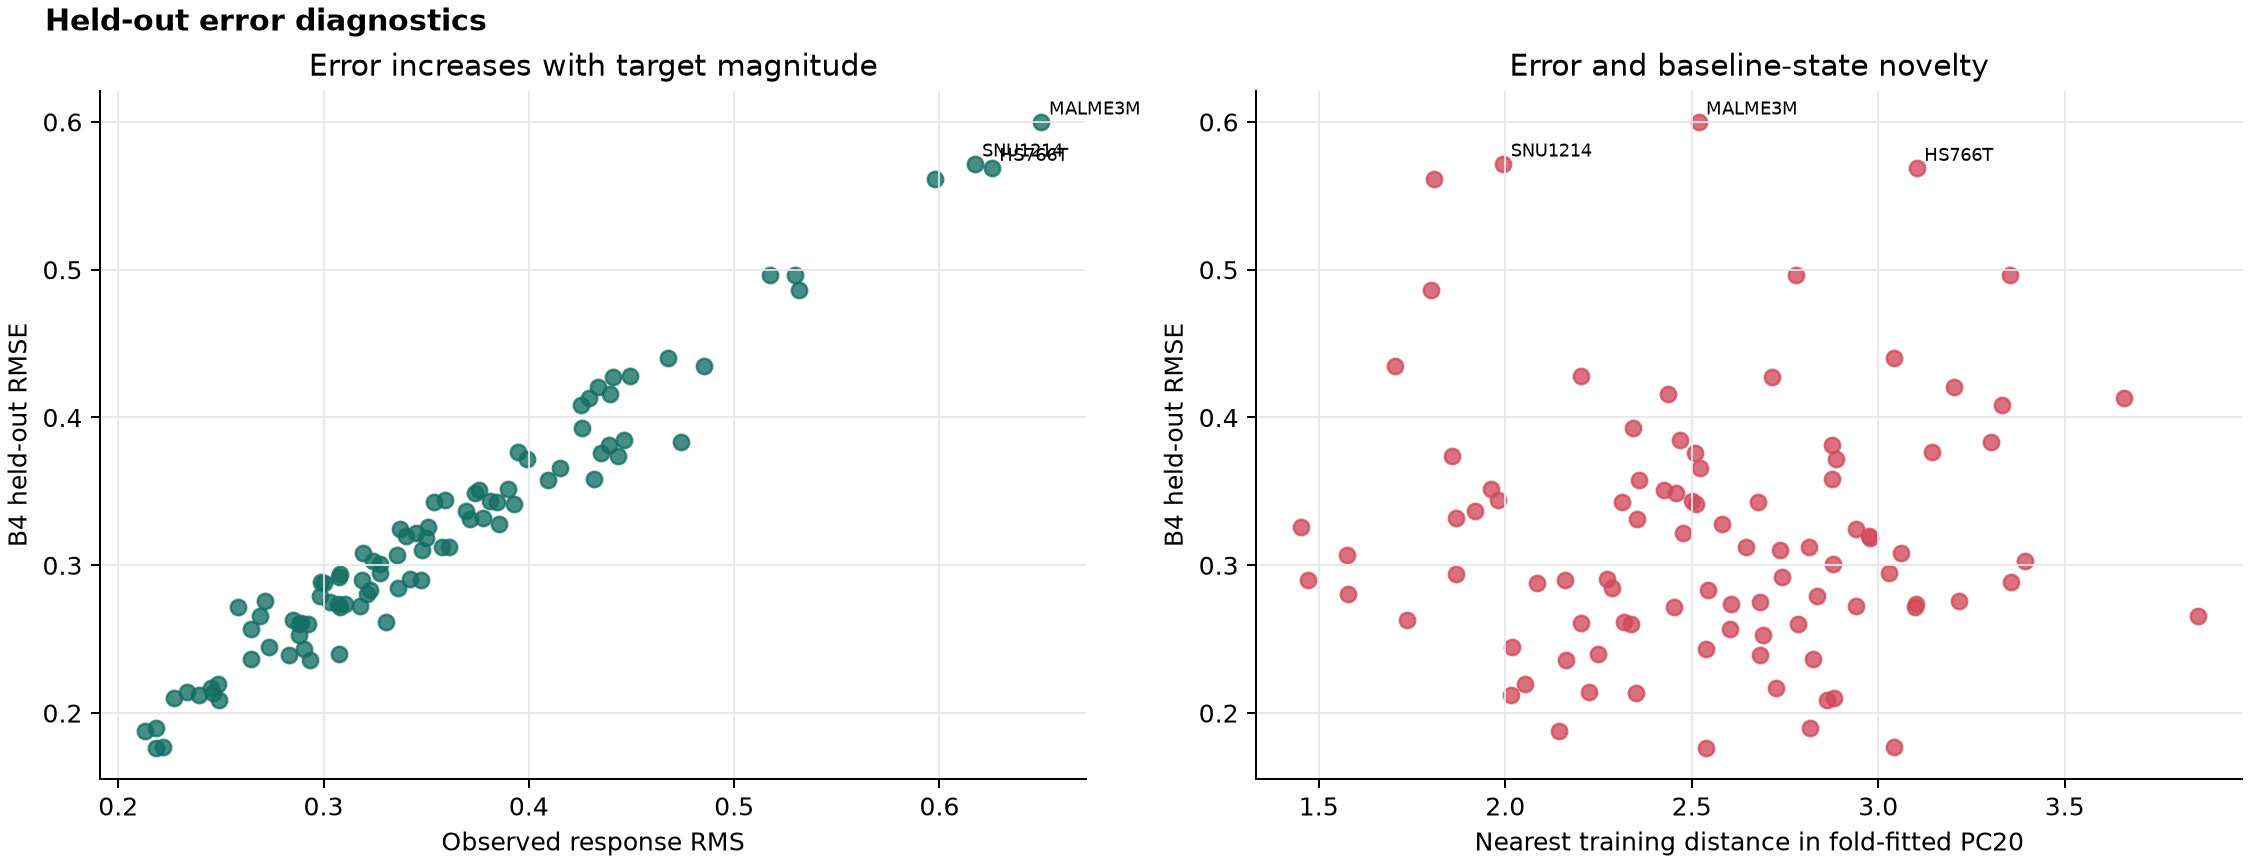

,family,outcome,predictor,effect,ci95_low,ci95_high,fdr_bh
26,error_factor,b4_rmse,response_rms,0.972806,0.947291,0.982578,0.000317
27,error_factor,b4_rmse,baseline_novelty,0.033371,-0.171922,0.238478,0.771323
28,error_factor,b4_rmse,min_condition_cells,-0.774982,-0.847136,-0.670772,0.000317
29,error_factor,b4_rmse,trametinib_sensitivity,0.217440,0.004590,0.409219,0.062776
30,error_factor_partial,b4_rmse,response_rms|min_condition_cells,0.953481,0.909327,0.970488,0.000317
31,error_factor_partial,b4_rmse,min_condition_cells|response_rms,-0.568730,-0.673743,-0.386018,0.000317
32,error_factor,cclr_rmse,response_rms,0.973818,0.951714,0.983753,0.000317
33,error_factor,cclr_rmse,baseline_novelty,0.034295,-0.167870,0.247644,0.771323
34,error_factor,cclr_rmse,min_condition_cells,-0.776210,-0.848437,-0.668018,0.000317
35,error_factor,cclr_rmse,trametinib_sensitivity,0.222021,0.012502,0.414697,0.049050


,case_type,cell_line,depmap_id,lineage,trametinib_sensitivity,braf_mut,kras_mut,b4_rmse,cclr_rmse,b4_pcc_context,response_rms,baseline_novelty,min_condition_cells
0,best,OAW42_OVARY,ACH-000704,ovary,0.218688,False,False,0.176539,0.177576,0.152073,0.218172,2.539053,148
1,best,NCIH1299_LUNG,ACH-000510,lung,0.391289,False,False,0.177328,0.177539,0.171894,0.222015,3.041060,119
2,best,786O_KIDNEY,ACH-000649,kidney,0.034952,False,False,0.187868,0.188396,0.215605,0.212960,2.144699,108
3,best,ACCMESO1_PLEURA,ACH-000086,mesothelioma,0.104091,False,False,0.189866,0.189849,0.141198,0.218305,2.817181,97
4,best,GCIY_STOMACH,ACH-000047,gastric,0.592849,False,False,0.209045,0.209812,0.133854,0.249072,2.863670,106
5,median,TEN_ENDOMETRIUM,ACH-000397,uterus,-0.148500,False,False,0.303020,0.303170,0.090303,0.323858,3.393025,35
6,median,OSRC2_KIDNEY,ACH-000159,kidney,0.195660,False,False,0.307193,0.307282,0.072175,0.335726,1.575216,35
7,median,LK2_LUNG,ACH-000769,lung,0.192899,False,False,0.308477,0.308549,0.084803,0.319252,3.061172,57
8,median,ISTMES1_PLEURA,ACH-000569,mesothelioma,0.015084,False,False,0.310203,0.311137,0.063814,0.347970,2.735959,39
9,median,NUGC3_STOMACH,ACH-000911,gastric,0.519279,False,False,0.312227,0.312612,0.106735,0.357798,2.644556,58


,cell_lines
error_type,
not_high_error,70
high_magnitude_target,22
baseline_novelty,2


In [4]:
display(Image(filename=str(root / "results/figures/prediction_error_drivers.png")))
display(associations.loc[associations["family"].str.startswith("error_factor"), [
    "family", "outcome", "predictor", "effect", "ci95_low", "ci95_high", "fdr_bh"
]])
display(cases)
display(errors["error_type"].value_counts().rename("cell_lines").to_frame())


## Takeaways

1. **생물학적 축**: response PC1은 sensitivity, BRAF/KRAS, lineage와 함께 변한다.
   E2F/G2M 억제가 sensitivity와 가장 강하게 연결되어 MEK 억제 뒤 후기 cell-cycle
   arrest가 약물 민감도의 주요 전사 축임을 지지한다.
2. **표적 난도**: 반응 RMS가 클수록 B4/CCLR 절대 RMSE도 커진다. 이는 RMSE의
   scale dependence를 포함하므로 개인화 실패만으로 읽으면 안 된다.
3. **측정 지원**: 최소 cell count가 낮을수록 오차가 크며 response RMS 통제 후에도
   partial ρ 약 −0.57로 남는다. pseudobulk Δ의 sampling noise가 실질적 요인이다.
4. **배제된 설명**: baseline novelty는 B4 오차와 거의 무관했다(ρ 약 0.03).
   따라서 이번 오차는 단순히 test line의 baseline이 training manifold에서 멀어서
   생겼다는 설명을 지지하지 않는다.

이 연결들은 관찰적이고 독립 biological replicate가 부족하므로 인과효과나
gene-level 확증으로 표현하지 않는다.